### Cell 1: Imports and Setup

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Adding src to path for modularity
sys.path.append(os.path.abspath('../src'))
from analysis_utils import load_data, test_stationarity, calculate_volatility

# Loading data
df = load_data('../data/BrentOilPrices.csv')
events = pd.read_csv('../data/external_events.csv')

print(f"Dataset loaded with {len(df)} rows.")
print(df.head()) # Verifying the start (1987)
print(df.tail()) # Verifying the end (2022)

Dataset loaded with 9011 rows.
            Price
Date             
1987-05-20  18.63
1987-05-21  18.45
1987-05-22  18.55
1987-05-25  18.60
1987-05-26  18.63
            Price
Date             
2022-11-08  96.85
2022-11-09  93.05
2022-11-10  94.25
2022-11-11  96.37
2022-11-14  93.59


### Cell 2: Trend Analysis 

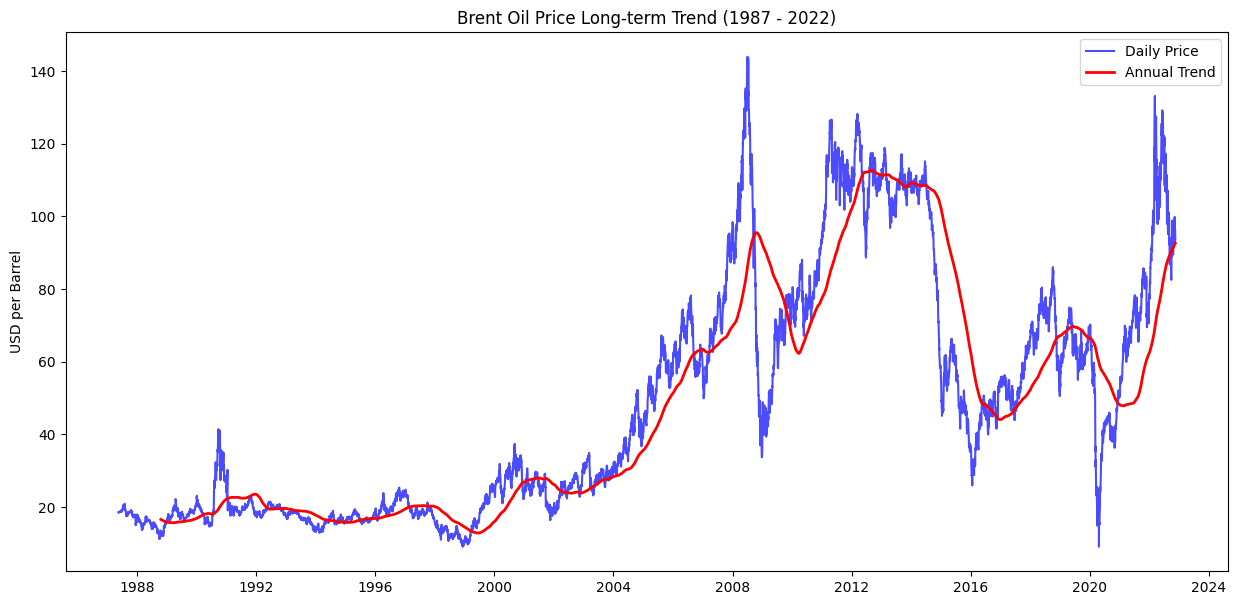

In [14]:
plt.figure(figsize=(15, 7))
plt.plot(df['Price'], label='Daily Price', color='blue', alpha=0.7)
plt.plot(df['Price'].rolling(window=365).mean(), label='Annual Trend', color='red', linewidth=2)
plt.title('Brent Oil Price Long-term Trend (1987 - 2022)')
plt.ylabel('USD per Barrel')
plt.legend()
plt.show()

### Cell 3: Stationarity Testing 

In [3]:
stats = test_stationarity(df['Price'])
print("--- ADF Test Results ---")
for key, value in stats.items():
    print(f"{key}: {value}")

# Logic for Task 1: 
# If p-value > 0.05, the data is non-stationary, suggesting we need 
# a Change Point Model to handle shifting means.

--- ADF Test Results ---
ADF Statistic: -1.9938560113924675
p-value: 0.28927350489340287
Critical Values: {'1%': np.float64(-3.4310783342658615), '5%': np.float64(-2.861861876398633), '10%': np.float64(-2.566941329781918)}
Is Stationary: False


### Cell 4: Volatility Patterns 

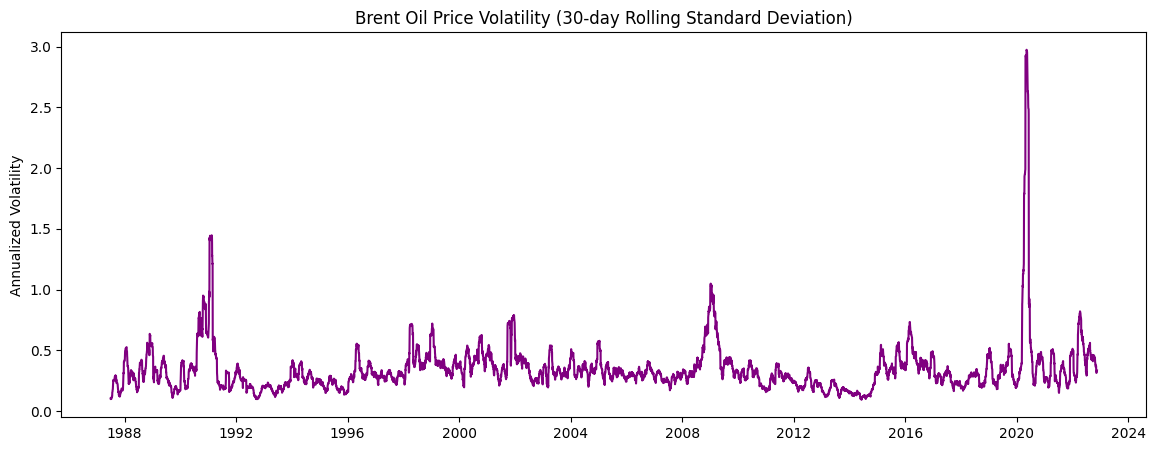

In [4]:
# Calculate 30-day annualized volatility
df['Volatility'] = calculate_volatility(df['Price'])

plt.figure(figsize=(14, 5))
plt.plot(df['Volatility'], color='purple')
plt.title('Brent Oil Price Volatility (30-day Rolling Standard Deviation)')
plt.ylabel('Annualized Volatility')
plt.show()

# High volatility clusters often correspond to the events in external_events.csv

### Cell 5: Event Overlay (Initial EDA Finding)

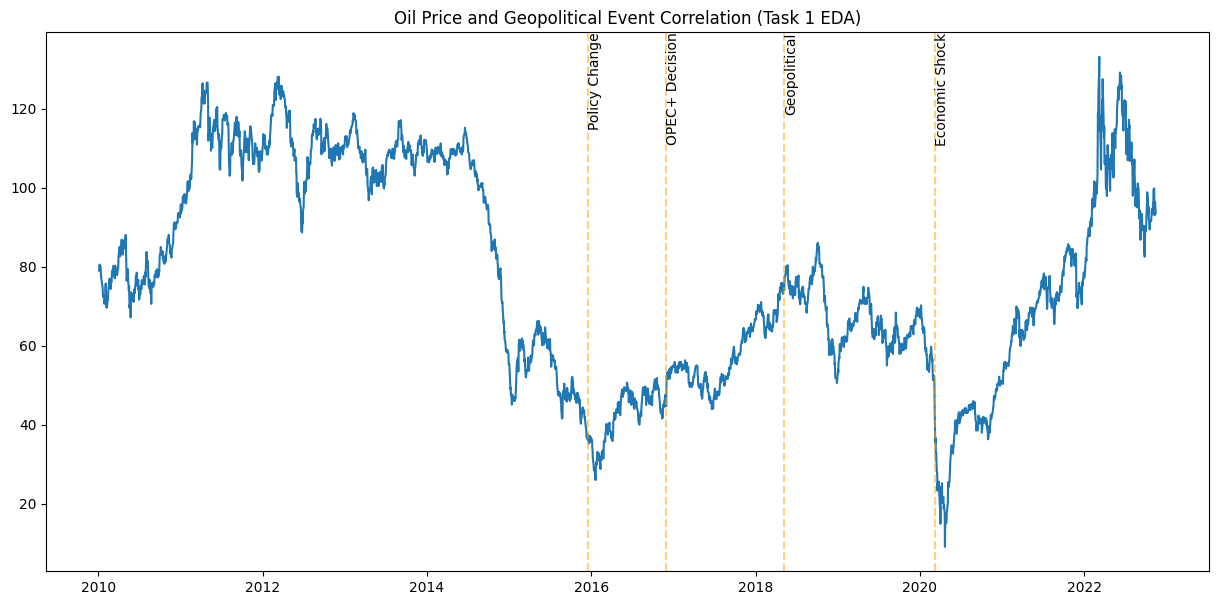

In [15]:
# Select a subset of data to see how events align
recent_data = df.loc['2010-01-01':]
plt.figure(figsize=(15, 7))
plt.plot(recent_data['Price'], label='Price')

# Plot the first 5 events from your CSV as vertical lines
for i, row in events.head(10).iterrows():
    event_date = pd.to_datetime(row['Date'])
    if event_date in recent_data.index:
        plt.axvline(x=event_date, color='orange', linestyle='--', alpha=0.5)
        plt.text(event_date, plt.ylim()[1], row['Type'], rotation=90, verticalalignment='top')

plt.title('Oil Price and Geopolitical Event Correlation (Task 1 EDA)')
plt.show()